pre-processing images...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


generating gratings...
smoothing phase...
saving images...


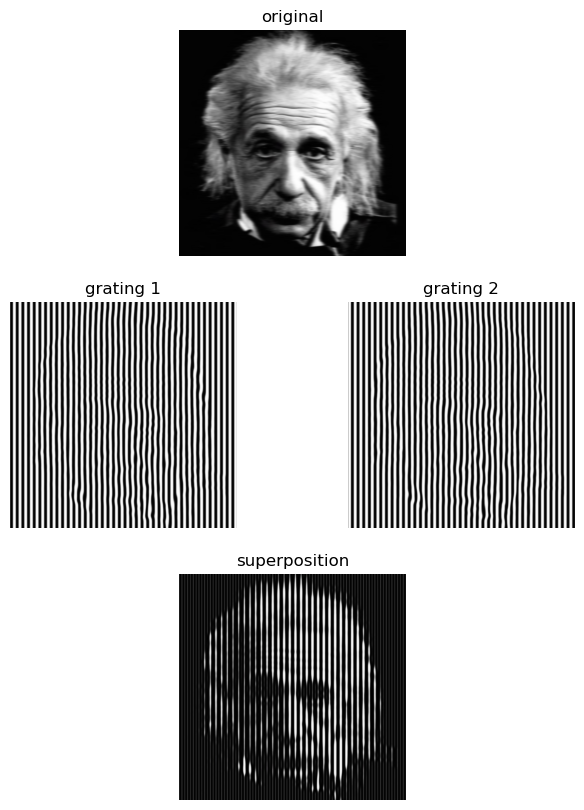

In [2]:
"""
Simple moire with a single color image
"""

import moirelib as m

T = 1./40        # grating period

print ('pre-processing images...')
img = m.prepImage('einstein', mag=2, sigma=(0,T/4., 0))
fig = m.figure(figsize=(8,10))
m.show(img, 311, 'original')

print ('generating gratings...')
carrier = m.makeCarrier(img.shape, T)
g1 = carrier-(1-img)/4
g2 = carrier+(1-img)/4

print ('smoothing phase...')
g1 = m.smoothenPhase(g1, 1e-3/T, 50)
g2 = m.smoothenPhase(g2, 1e-3/T, 50)

print ('saving images...')
g1 = m.makeGrating(g1)
g2 = m.makeGrating(g2)
m.show(g1,323, 'grating 1')
m.show(g2,324, 'grating 2')
m.show(g1*g2, 313, 'superposition')

fig.savefig('./results/moire1.png', dpi=300)

In [ ]:
T = 1./40  # grating period as fraction of image width
offset = 1./8  # offset as a fraction of the image height

print ('Loading images...')
img = (
    m.prepImage('audrey', mag=4, sigma=(0,T/4,0)), 
    m.prepImage('mona',   mag=4, sigma=(0,T/4,0))
    )
fig = m.figure(figsize=(8,10))
m.show(img[0], 321, 'original')
m.show(img[1], 322, 'original')

print ('generating gratings...')
offset = round(offset*img[0].shape[0])  # convert to pixels
dims = img[0].shape
dims = (dims[0]+offset,dims[1],dims[2])
g1 = m.makeCarrier(dims, T)
g2 = g1.copy()

# iterative adjustment of gratings to images
L = 0.04       # learning rate
niter = 501    # of iterations

for i in range(niter):
    if i % 25 == 0:
        print ("iteration [%4d/%4d]" % (i, niter))

    # update gratings
    err1 = (1-img[0])/2 - (g1[:-offset,:,:] - g2[offset:,:,:])
    err2 = (1-img[1])/2 - (g2[:-offset,:,:] - g1[offset:,:,:])
    g1[:-offset,:,:] += L*err1
    g2[offset:,:,:] -= L*err1
    g2[:-offset,:,:] += L*err2
    g1[offset:,:,:] -= L*err2

    # enforce grating smoothness by clipping the laplacian
    g1 = m.smoothenPhase(g1, 1e-4/T)

print ('saving image...')
g1 = m.makeGrating(g1)
g2 = m.makeGrating(g2)

# visualize gratings 
m.show(g1, 323, 'grating 1')
m.show(g2, 324, 'grating 2')

# visualize superpositions
e = m.ones((offset, dims[1], dims[2]))
s1 = m.vstack((e, g1))*m.vstack((g2, e)) 
s2 = m.vstack((e, g2))*m.vstack((g1, e))
m.show(s1, 325, 'superposition 1')
m.show(s2, 326, 'superposition 2')

fig.savefig('./results/moire2.png', dpi=300)

In [ ]:
T = 1./40        # grating period
offset = 1./8    # superposition offset

print ('pre-processing images...')
img = m.prepImage('audrey', mag=4, sigma=(0,T/4., 0))
fig = m.figure(figsize=(8,10))
m.show(img, 311, 'original')

# carrier phase image: horizontal gradient with slope 1/T
offset = round(offset*img.shape[0])  # convert to pixels
dims = (img.shape[0]+offset, img.shape[1], img.shape[2])
g = m.makeCarrier(dims, T)

print ('computing gratings...')
L = 0.04    # learning rate
niter = 501   # of iterations

for i in range(niter):
    if i % 25 == 0:
        print ("iteration [%4d/%4d]" % (i, niter))

    # update grating
    err = (1-img)/2 - (g[0:-offset,:,:] - g[offset:,:,:])
    g[0:-offset,:,:] += L*err
    g[offset:,:,:]   -= L*err
    g = m.smoothenPhase(g, 1e-4/T)

print ('saving image...')
g = m.makeGrating(g)

# visualize gratings 
m.show(g, 312, 'grating')

# visualize superpositions
e = m.ones((offset, img.shape[1], img.shape[2]))
s = m.vstack((e, g))*m.vstack((g, e)) 
m.show(s, 313, 'superposition')

fig.savefig('./results/moire3.png', dpi=300)